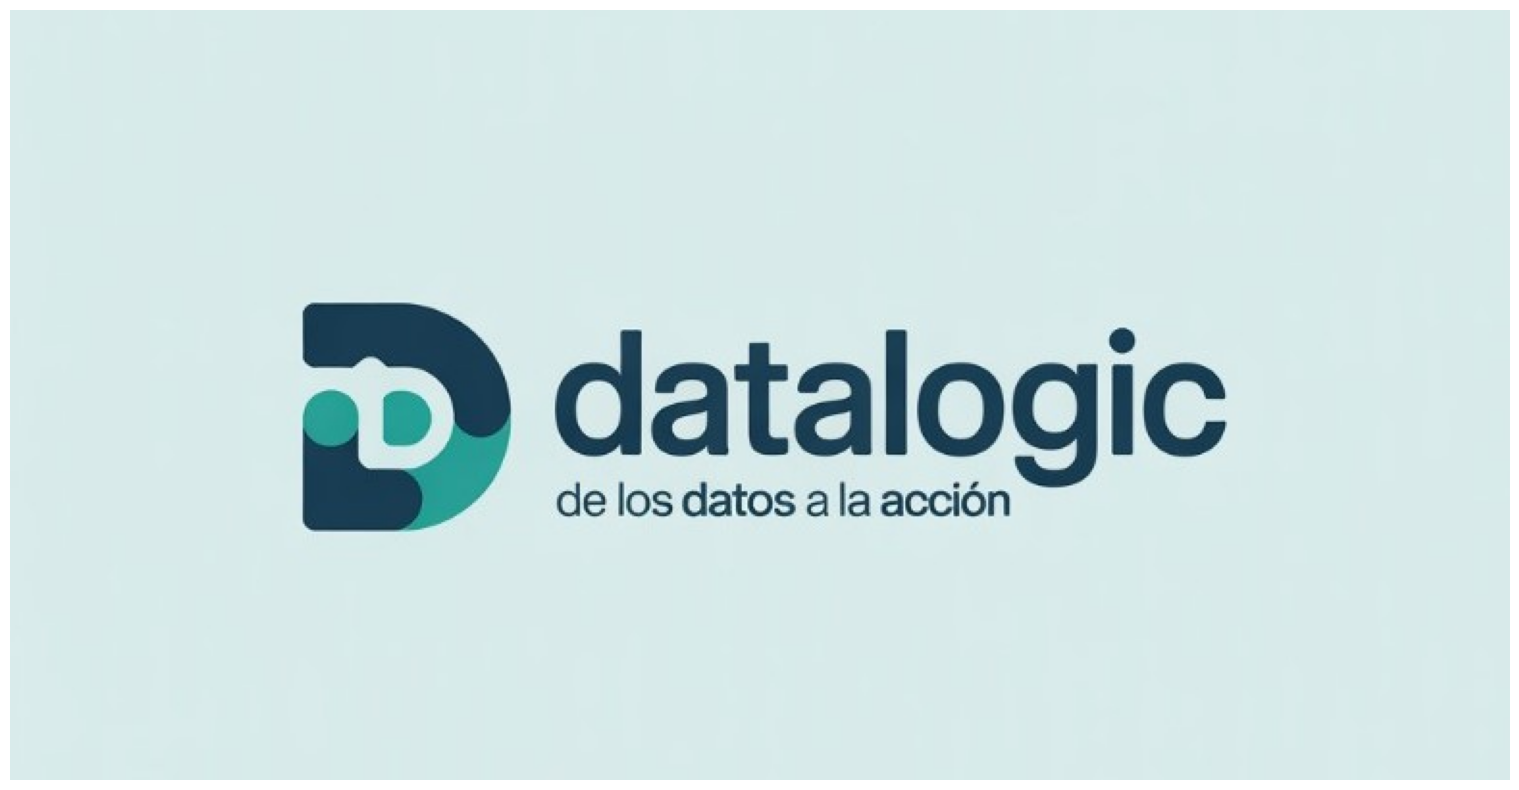

In [3]:
r.Imagen('../assets/consultora_logo.jpeg', (20,10))

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## para utilizar en google colab

In [1]:
import numpy as np
import pandas as pd
# import os # en el caso que se trabaje en el entorno de colab

# os.chdir('/content/drive/MyDrive/NoCountry_RiesgoCrediticio/recursos_y_notebooks') # en el caso de que se trabaje en google colab

%load_ext autoreload
%autoreload 2

import resources as r

# Este codigo Pone un limite grande para el ancho y sin limite para el largo de un output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 1000) 
pd.set_option('display.width', 1000)

## Instanciamos los Datos

In [2]:
churn_data = pd.read_csv('../data/1.5 synthetic/churn_data.csv')

# Churn_data

In [3]:
churn_data.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,nps_score,tx_count_30d,avg_tx_amount,failed_tx,support_tickets
0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,320,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0,4,74,908.82,45,0
1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,18,306.34,12838.38,10,NaN,Yes,No,Yes,Solved,Quality Customer Care,0,3,73,536.62,33,5
2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,102,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1,4,27,668.29,12,2
3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,193,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1,6,32,508.17,41,9
4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,40,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1,6,18,27.63,41,3


## Reemplazamos datos NaN

In [4]:
churn_data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           36992 non-null  int64  
 1   gender                        36992 non-null  object 
 2   security_no                   36992 non-null  object 
 3   region_category               31564 non-null  object 
 4   membership_category           36992 non-null  object 
 5   joining_date                  36992 non-null  object 
 6   joined_through_referral       36992 non-null  object 
 7   referral_id                   36992 non-null  object 
 8   preferred_offer_types         36704 non-null  object 
 9   medium_of_operation           36992 non-null  object 
 10  internet_option               36992 non-null  object 
 11  last_visit_time               36992 non-null  object 
 12  days_since_last_login         36992 non-null  int64  
 13  a

In [5]:
churn_data.isna().sum()

age                                0
gender                             0
security_no                        0
region_category                 5428
membership_category                0
joining_date                       0
joined_through_referral            0
referral_id                        0
preferred_offer_types            288
medium_of_operation                0
internet_option                    0
last_visit_time                    0
days_since_last_login              0
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                3443
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
churn_risk_score                   0
nps_score                          0
tx_count_30d                       0
avg_tx_amount                      0
failed_tx                          0
s

In [6]:
# limpiamos los datos nan
# primero del campo region_category
churn_data[churn_data['region_category'].isna()].head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,nps_score,tx_count_30d,avg_tx_amount,failed_tx,support_tickets
7,42,M,4UJ1551,NaN,No Membership,12-07-2016,?,CID56614,Credit/Debit Card Offers,Both,Fiber_Optic,7:52:43,135,429.11,44554.82,24,568.08,No,Yes,Yes,Unsolved,Poor Product Quality,1,3,33,633.10,24,8
32,11,F,ZYEBIID,NaN,Gold Membership,28-07-2016,Yes,CID26584,Without Offers,Desktop,Wi-Fi,9:36:43,198,185.53,60143.68,4,836.08,Yes,No,Yes,Solved in Follow-up,User Friendly Website,0,2,15,34.37,6,6
37,26,M,06HDP63,NaN,No Membership,29-11-2017,Yes,CID39260,Without Offers,Desktop,Wi-Fi,14:55:59,157,215.89,41979.65,9,NaN,No,Yes,No,Not Applicable,Too many ads,1,8,16,646.22,6,1
61,44,F,YN0D4XB,NaN,No Membership,23-08-2016,Yes,CID35687,Without Offers,Both,Wi-Fi,22:22:17,247,283.49,7603.71,Error,553.45,Yes,Yes,Yes,Unsolved,No reason specified,1,1,3,831.21,31,6
64,10,M,PXDXAK3,NaN,Basic Membership,08-06-2015,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Fiber_Optic,11:07:18,300,31.67,25436.23,Error,656.67,No,Yes,No,Not Applicable,Poor Website,1,5,8,297.47,36,6


In [7]:
churn_data['region_category'] = churn_data['region_category'].fillna('?')

In [8]:
# ahora el campo preferred_offer_types
churn_data['preferred_offer_types'] = churn_data['preferred_offer_types'].fillna('?')

In [9]:
#  para el campo campo points_in_wallet que es un campo float, vamos a realizar el reemplazo de los valores
#  NaN con el valor de la media del campo
# primero vamos a asegurarnos el grado de dispersion de datos midiendo la desviacion estandr de los datos.

# obtenemos la desviacion estandar del campo campo points_in_wallet
ds = churn_data['points_in_wallet'].std().round(2)
ds

194.06

In [10]:
# generamos el valor de la media
media = churn_data['points_in_wallet'].mean().round(2)
media

686.88

In [11]:
# ahora reemplazamos los valores NaN del campo points_in_wallet por el valor de la media muestral
churn_data['points_in_wallet'] = churn_data['points_in_wallet'].fillna(media)

In [12]:
churn_data.head(10)

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,nps_score,tx_count_30d,avg_tx_amount,failed_tx,support_tickets
0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,320,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0,4,74,908.82,45,0
1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,18,306.34,12838.38,10,686.88,Yes,No,Yes,Solved,Quality Customer Care,0,3,73,536.62,33,5
2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,102,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1,4,27,668.29,12,2
3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,193,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1,6,32,508.17,41,9
4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,40,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1,6,18,27.63,41,3
5,13,M,PSG1LGF,City,Gold Membership,08-01-2016,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,6:46:07,119,433.62,13884.77,24,722.27,Yes,No,Yes,Unsolved,No reason specified,0,1,77,433.15,48,1
6,21,M,R3CX1EA,Town,Gold Membership,19-03-2015,Yes,CID24708,Gift Vouchers/Coupons,Desktop,Mobile_Data,11:40:04,261,55.38,8982.50,28,756.21,Yes,No,Yes,Solved in Follow-up,No reason specified,0,1,71,348.69,21,9
7,42,M,4UJ1551,?,No Membership,12-07-2016,?,CID56614,Credit/Debit Card Offers,Both,Fiber_Optic,7:52:43,135,429.11,44554.82,24,568.08,No,Yes,Yes,Unsolved,Poor Product Quality,1,3,33,633.10,24,8
8,44,M,0481QNQ,Village,Silver Membership,14-12-2016,No,xxxxxxxx,Without Offers,Smartphone,Fiber_Optic,6:50:10,84,191.07,18362.31,20,686.88,Yes,No,Yes,Solved in Follow-up,Poor Customer Service,0,2,78,293.17,3,9
9,45,F,ZHP4MCR,Town,No Membership,30-11-2016,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,19:10:16,98,97.31,19244.16,28,706.23,No,Yes,Yes,No Information Available,Poor Customer Service,1,8,87,935.10,21,3


In [13]:
churn_data.isna().sum()

age                             0
gender                          0
security_no                     0
region_category                 0
membership_category             0
joining_date                    0
joined_through_referral         0
referral_id                     0
preferred_offer_types           0
medium_of_operation             0
internet_option                 0
last_visit_time                 0
days_since_last_login           0
avg_time_spent                  0
avg_transaction_value           0
avg_frequency_login_days        0
points_in_wallet                0
used_special_discount           0
offer_application_preference    0
past_complaint                  0
complaint_status                0
feedback                        0
churn_risk_score                0
nps_score                       0
tx_count_30d                    0
avg_tx_amount                   0
failed_tx                       0
support_tickets                 0
dtype: int64

## Normalizamos Etiquetas

In [14]:
# veamos si es correcta la asignacion de tipo de dato para cada columna del dataframe
r.verificar_tipo_datos(churn_data)

,nombre_campo,tipo_datos,no_nulos_%,nulos_%,nulos
0,age,[<class 'int'>],100.0,0.0,0
1,gender,[<class 'str'>],100.0,0.0,0
2,security_no,[<class 'str'>],100.0,0.0,0
3,region_category,[<class 'str'>],100.0,0.0,0
4,membership_category,[<class 'str'>],100.0,0.0,0
5,joining_date,[<class 'str'>],100.0,0.0,0
6,joined_through_referral,[<class 'str'>],100.0,0.0,0
7,referral_id,[<class 'str'>],100.0,0.0,0
8,preferred_offer_types,[<class 'str'>],100.0,0.0,0
9,medium_of_operation,[<class 'str'>],100.0,0.0,0


In [15]:
churn_data.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,nps_score,tx_count_30d,avg_tx_amount,failed_tx,support_tickets
0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,320,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0,4,74,908.82,45,0
1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,18,306.34,12838.38,10,686.88,Yes,No,Yes,Solved,Quality Customer Care,0,3,73,536.62,33,5
2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,102,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1,4,27,668.29,12,2
3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,193,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1,6,32,508.17,41,9
4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,40,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1,6,18,27.63,41,3


In [16]:
# reemplazamos etiqueta 'Unknown' por valor '?' en el campo gender
churn_data['gender'] = [x.replace('Unknown', '?') for x in churn_data['gender']]

In [17]:
# verificamos los valores presentes en el campo 'avg_frequency_login_days'
churn_data['avg_frequency_login_days'].value_counts()

Error           3522
13              1394
19              1365
8               1361
14              1355
17              1349
6               1336
10              1334
18              1331
12              1327
15              1327
5               1323
16              1319
9               1314
7               1304
11              1249
27              1121
23              1111
28              1107
29              1102
25              1087
20              1069
26              1065
21              1060
24              1055
22              1054
4                274
3                255
1                253
2                242
30                 4
50.87485175        1
-5.511716737       1
-17.07968464       1
-24.68438876       1
48.4891246         1
4.842593978        1
28.16282391        1
-1.879808564       1
32.46020929        1
28.35374278        1
44.01452226        1
48.11801791        1
-10.1884666        1
49.36793711        1
-4.202424119       1
2.970222429        1
-11.06819025 

In [18]:
# obtenemos el valor de la media para los valores del campo 'avg_frequency_login_days'
# primero reemplazamos los valores 'Error' y 'F' dentro del campo

churn_data['avg_frequency_login_days'] = churn_data['avg_frequency_login_days'].replace(['Error','F'], np.nan)

# transformamos los valores del campo a un formato numerico decimal
churn_data['avg_frequency_login_days'] = churn_data['avg_frequency_login_days'].astype(float)

In [19]:
# redondeamos los valores numericos a 2 decimales
churn_data['avg_frequency_login_days'] = churn_data['avg_frequency_login_days'].round(2)

In [20]:
# obtenemos la media muestral y reemplazamos los valores NaN por el valor de la media
media = churn_data['avg_frequency_login_days'].mean()

# reemplazamos
churn_data['avg_frequency_login_days'].fillna(media, inplace= True)

In [21]:
# a los valores en el campo ''avg_frequency_login_days'' los redondeamos a 2 digitos decimales para su posterior cambio de tipo de dato
churn_data['avg_frequency_login_days'] = [round(float(x),2) for x in churn_data['avg_frequency_login_days']]

## Reasignamos tipo de dato para el campo

In [22]:
for columna in churn_data.columns:
    if churn_data[columna].dtype == 'object':
        print(columna)
        print(churn_data[columna].unique())
        print()
        print()
    else:
        continue

gender
['F' 'M' '?']


security_no
['XW0DQ7H' '5K0N3X1' '1F2TCL3' ... 'XK1IM9H' 'K6VTP1Z' 'LBX0GLR']


region_category
['Village' 'City' 'Town' '?']


membership_category
['Platinum Membership' 'Premium Membership' 'No Membership'
 'Gold Membership' 'Silver Membership' 'Basic Membership']


joining_date
['17-08-2017' '28-08-2017' '11-11-2016' ... '11-12-2017' '25-09-2016'
 '15-04-2017']


joined_through_referral
['No' '?' 'Yes']


referral_id
['xxxxxxxx' 'CID21329' 'CID12313' ... 'CID60808' 'CID10431' 'CID45477']


preferred_offer_types
['Gift Vouchers/Coupons' 'Credit/Debit Card Offers' 'Without Offers' '?']


medium_of_operation
['?' 'Desktop' 'Smartphone' 'Both']


internet_option
['Wi-Fi' 'Mobile_Data' 'Fiber_Optic']


last_visit_time
['16:08:02' '12:38:13' '22:53:21' ... '4:14:05' '9:50:03' '1:39:52']


used_special_discount
['Yes' 'No']


offer_application_preference
['Yes' 'No']


past_complaint
['No' 'Yes']


complaint_status
['Not Applicable' 'Solved' 'Solved in Follow-up' 'Un

In [23]:
# se deben reasignar los tipos de datos para los campos last_visit_time y joining_date a tipo de dato temporal (es decir, referido a tiempo)

churn_data['last_visit_time'] = pd.to_datetime(churn_data['last_visit_time'], format= '%H:%M:%S').dt.time

churn_data['joining_date'] = pd.to_datetime(churn_data['joining_date'], format='%d-%m-%Y')





## Eliminar campos innecesarios

In [24]:
# los campos de referencia security_no y referral_id no aportan informacion significativa y pertinente para el analisis por lo que seran descartados

churn_data.drop(columns= ['security_no', 'referral_id'], inplace= True)

In [25]:
churn_data.head()

,age,gender,region_category,membership_category,joining_date,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,nps_score,tx_count_30d,avg_tx_amount,failed_tx,support_tickets
0,18,F,Village,Platinum Membership,2017-08-17,No,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,320,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0,4,74,908.82,45,0
1,32,F,City,Premium Membership,2017-08-28,?,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,18,306.34,12838.38,10.0,686.88,Yes,No,Yes,Solved,Quality Customer Care,0,3,73,536.62,33,5
2,44,F,Town,No Membership,2016-11-11,Yes,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,102,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1,4,27,668.29,12,2
3,37,M,City,No Membership,2016-10-29,Yes,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,193,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1,6,32,508.17,41,9
4,31,F,City,No Membership,2017-09-12,No,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,40,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1,6,18,27.63,41,3


## Guardamos los datos

In [26]:
# Guardamos el dataframe como un fichero de tipo .csv en el directorio especificado
churn_data.to_csv('../data/2. stage/churn_FV.csv', index= False)